In [13]:
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
file = "C:\\Users\\eyasf\\OneDrive\\Desktop\\projet_raies\\raw_data\\FX Data.xlsx"

xls = pd.ExcelFile(file)
print(xls.sheet_names)

['InterBancaire', 'BCT Fixing EUR', 'BCT Fixing USD', 'EUR-GBP-JPY vs USD']


In [6]:
Bct_fixing_USD = pd.read_excel(xls, "BCT Fixing USD")
EUR_GBP_JPY_vs_USD = pd.read_excel(xls, "EUR-GBP-JPY vs USD")
print(Bct_fixing_USD.head())
print(EUR_GBP_JPY_vs_USD.head())

  Exchange Date     Bid     Ask  Mid Price
0    2020-04-10  2.9049  2.9079    2.90640
1    2020-04-13  2.8954  2.8982    2.89680
2    2020-04-14  2.8877  2.8905    2.88910
3    2020-04-15  2.8938  2.8966    2.89520
4    2020-04-16  2.8999  2.9028    2.90135
        Date    EUR=    GBP=    JPY=
0        NaT   Close   Close   Close
1 2020-04-09  1.0927  1.2455  108.46
2 2020-04-10  1.0935  1.2452  108.46
3 2020-04-13  1.0913  1.2507  107.76
4 2020-04-14  1.0979  1.2623   107.2


In [8]:
# Clean BCT FIXING USD
USD = Bct_fixing_USD.copy()
USD = USD[['Exchange Date', 'Mid Price']]
USD = USD.rename(columns={'Exchange Date': 'Date', 'Mid Price': 'USD_TND'})
USD['Date'] = pd.to_datetime(USD['Date'], format='%d/%m/%Y')
USD = USD.dropna()
USD = USD.sort_values('Date')
print(USD.head())

        Date  USD_TND
0 2020-04-10  2.90640
1 2020-04-13  2.89680
2 2020-04-14  2.88910
3 2020-04-15  2.89520
4 2020-04-16  2.90135


In [10]:
# Clean EUR-GBP-JPY vs USD
fx = EUR_GBP_JPY_vs_USD.copy()


fx = fx.dropna(subset=['Date'])


fx = fx.rename(columns={
    'EUR=': 'EURUSD',
    'GBP=': 'GBPUSD',
    'JPY=': 'USDJPY'
})

fx['Date'] = pd.to_datetime(fx['Date'])

fx['EURUSD'] = pd.to_numeric(fx['EURUSD'], errors='coerce')
fx['GBPUSD'] = pd.to_numeric(fx['GBPUSD'], errors='coerce')
fx['USDJPY'] = pd.to_numeric(fx['USDJPY'], errors='coerce')

fx = fx.dropna()
fx = fx.sort_values('Date')

print(USD.head())

        Date  USD_TND
0 2020-04-10  2.90640
1 2020-04-13  2.89680
2 2020-04-14  2.88910
3 2020-04-15  2.89520
4 2020-04-16  2.90135


In [11]:
# merge datasets on Date 
data = pd.merge(USD, fx , on='Date', how='inner')

data = data.sort_values('Date')

print(data.head())
print(data.info())
print(data.isna().sum())

        Date  USD_TND  EURUSD  GBPUSD  USDJPY
0 2020-04-10  2.90640  1.0935  1.2452  108.46
1 2020-04-13  2.89680  1.0913  1.2507  107.76
2 2020-04-14  2.88910  1.0979  1.2623  107.20
3 2020-04-15  2.89520  1.0907  1.2514  107.47
4 2020-04-16  2.90135  1.0835  1.2455  107.94
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1422 entries, 0 to 1421
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype         
---  ------   --------------  -----         
 0   Date     1422 non-null   datetime64[ns]
 1   USD_TND  1422 non-null   float64       
 2   EURUSD   1422 non-null   float64       
 3   GBPUSD   1422 non-null   float64       
 4   USDJPY   1422 non-null   float64       
dtypes: datetime64[ns](1), float64(4)
memory usage: 55.7 KB
None
Date       0
USD_TND    0
EURUSD     0
GBPUSD     0
USDJPY     0
dtype: int64


In [ ]:
# Visualize the data + interpretation

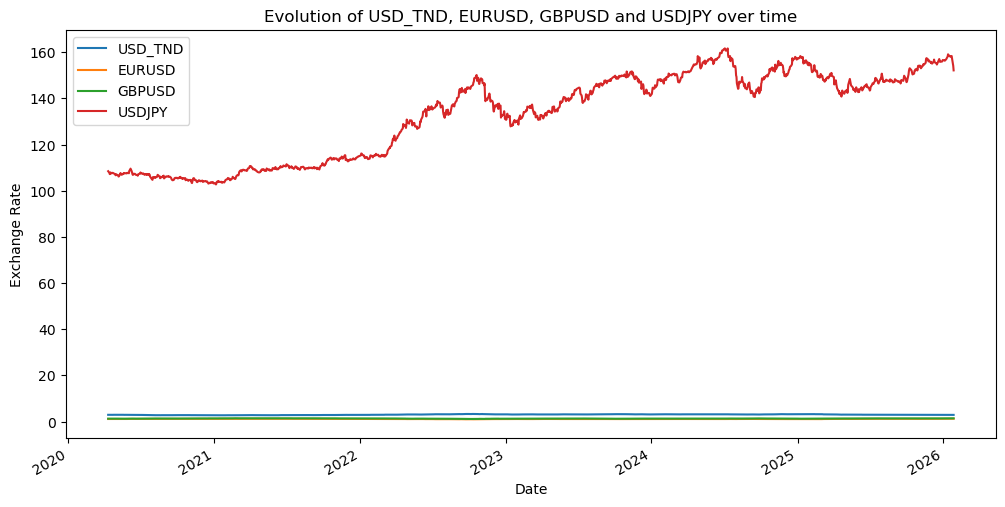

In [ ]:
#step 1 : global view of the data 
data.set_index('Date')[['USD_TND','EURUSD','GBPUSD','USDJPY']].plot(figsize=(12,6))
plt.title('Evolution of USD_TND, EURUSD, GBPUSD and USDJPY over time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate')
plt.legend()
plt.show()

In [ ]:
#The variables are expressed in different scales, making direct comparison in levels misleading

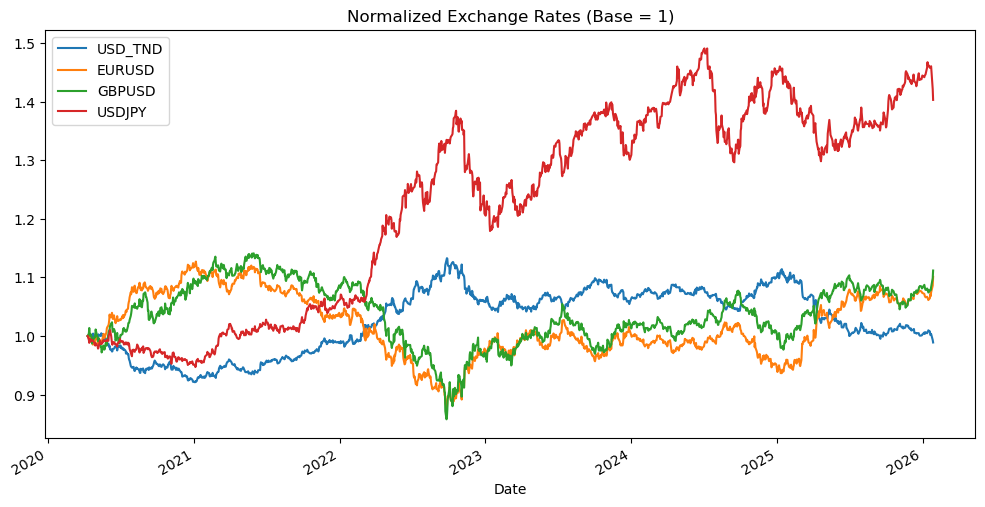

In [15]:
normalized = data.set_index('Date')[['USD_TND','EURUSD','GBPUSD','USDJPY']]

normalized = normalized / normalized.iloc[0]

normalized.plot(figsize=(12,6))
plt.title("Normalized Exchange Rates (Base = 1)")
plt.show()

In [ ]:
#The normalized series reveal that USD/TND evolves more smoothly than global FX rates, suggesting that the fixing only partially incorporates international movements. This supports the use of a regression framework in log-returns to capture dynamic relationships

In [16]:
# step 2 : detect anomalies
data.describe()

,Date,USD_TND,EURUSD,GBPUSD,USDJPY
count,1422,1422.000000,1422.000000,1422.000000,1422.000000
mean,2023-02-02 11:21:31.139240704,2.985631,1.111694,1.289113,132.449819
min,2020-04-10 00:00:00,2.677500,0.959200,1.068400,102.720000
25%,2021-09-06 06:00:00,2.852800,1.072500,1.245700,110.612500
50%,2023-01-24 12:00:00,3.039425,1.097250,1.281000,137.445000
75%,2024-06-26 18:00:00,3.114700,1.165875,1.342175,148.367500
max,2026-01-27 00:00:00,3.292300,1.232500,1.420900,161.680000
std,NaN,0.158919,0.059088,0.064543,18.629781


In [17]:
data[['USD_TND','EURUSD','GBPUSD','USDJPY']].diff().abs().max()

USD_TND    0.0536
EURUSD     0.0245
GBPUSD     0.0401
USDJPY     5.4900
dtype: float64

In [ ]:
# no anomalies detected, the maximum daily change is reasonable for all series, especially considering the volatility of global FX rates compared to the more stable USD/TND fixing.

In [ ]:
# step 3 : log returns to instaure stationarity
import numpy as np

returns = data.copy()

returns['r_USD_TND'] = np.log(returns['USD_TND']).diff()
returns['r_EURUSD'] = np.log(returns['EURUSD']).diff()
returns['r_GBPUSD'] = np.log(returns['GBPUSD']).diff()
returns['r_USDJPY'] = np.log(returns['USDJPY']).diff()


returns = returns.dropna()

returns.head()


,Date,USD_TND,EURUSD,GBPUSD,USDJPY,r_USD_TND,r_EURUSD,r_GBPUSD,r_USDJPY
1,2020-04-13,2.89680,1.0913,1.2507,107.76,-0.003309,-0.002014,0.004407,-0.006475
2,2020-04-14,2.88910,1.0979,1.2623,107.20,-0.002662,0.006030,0.009232,-0.005210
3,2020-04-15,2.89520,1.0907,1.2514,107.47,0.002109,-0.006580,-0.008673,0.002515
4,2020-04-16,2.90135,1.0835,1.2455,107.94,0.002122,-0.006623,-0.004726,0.004364
5,2020-04-17,2.90870,1.0876,1.2499,107.51,0.002530,0.003777,0.003526,-0.003992


In [19]:
returns.describe()

,Date,USD_TND,EURUSD,GBPUSD,USDJPY,r_USD_TND,r_EURUSD,r_GBPUSD,r_USDJPY
count,1421,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000,1421.000000
mean,2023-02-03 04:43:44.630541568,2.985687,1.111707,1.289143,132.466702,-0.000008,0.000068,0.000075,0.000238
min,2020-04-13 00:00:00,2.677500,0.959200,1.068400,102.720000,-0.017425,-0.020094,-0.036272,-0.038578
25%,2021-09-07 00:00:00,2.852700,1.072500,1.245700,110.620000,-0.001767,-0.002737,-0.003040,-0.002803
50%,2023-01-25 00:00:00,3.039650,1.097300,1.281200,137.470000,0.000000,0.000000,0.000236,0.000442
75%,2024-06-27 00:00:00,3.114700,1.165900,1.342200,148.370000,0.001859,0.002894,0.003253,0.003432
max,2026-01-27 00:00:00,3.292300,1.232500,1.420900,161.680000,0.012546,0.022116,0.030953,0.020701
std,NaN,0.158961,0.059107,0.064555,18.625456,0.003220,0.004759,0.005441,0.005951


In [ ]:
#interpretation : the means are close to zero, with USD/TND showing a slightly higher average return. The standard deviations indicate that global FX rates are more volatile than the USD/TND fixing, which is expected given the controlled nature of the latter. The maximum and minimum returns also reflect this difference in volatility, with global FX rates exhibiting larger swings compared to the more stable USD/TND.
#insight model : the fixing integrates just a portion of the international movements

In [20]:
#step 4 : correlation analysis
correlation_matrix = returns[['r_USD_TND', 'r_EURUSD', 'r_GBPUSD', 'r_USDJPY']].corr()
print(correlation_matrix)

           r_USD_TND  r_EURUSD  r_GBPUSD  r_USDJPY
r_USD_TND   1.000000 -0.623689 -0.494772  0.372127
r_EURUSD   -0.623689  1.000000  0.744765 -0.477099
r_GBPUSD   -0.494772  0.744765  1.000000 -0.424755
r_USDJPY    0.372127 -0.477099 -0.424755  1.000000


In [ ]:
# To take into account : the corrolation between the variables wich may affect the regression results wich may suggest to search for a more complex model 

In [21]:
# Approach 1 : linear regression with OLS
import statsmodels.api as sm
X= returns[['r_EURUSD', 'r_GBPUSD', 'r_USDJPY']]
Y= returns['r_USD_TND']
X= sm.add_constant(X)
model = sm.OLS(Y,X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              r_USD_TND   R-squared:                       0.397
Model:                            OLS   Adj. R-squared:                  0.396
Method:                 Least Squares   F-statistic:                     311.6
Date:                Sun, 26 Apr 2026   Prob (F-statistic):          2.53e-155
Time:                        13:19:35   Log-Likelihood:                 6498.3
No. Observations:                1421   AIC:                        -1.299e+04
Df Residuals:                    1417   BIC:                        -1.297e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       7.536e-06   6.65e-05      0.113      0.9

In [ ]:
# Interpretation : see the doc

In [22]:
# Approach 1 : linear regression with Rolling window
window_size = 60
X= returns[['r_EURUSD', 'r_GBPUSD', 'r_USDJPY']]
Y= returns['r_USD_TND']
X= sm.add_constant(X)
betas = pd.DataFrame(index=returns.index[window_size-1:], columns=['const', 'EUR', 'GBP', 'JPY'])
for i in range(window_size, len(returns)+1):
    X_window = X.iloc[i-window_size:i]
    Y_window = Y.iloc[i-window_size:i]
    model_window = sm.OLS(Y_window, X_window).fit()
    betas.iloc[i-window_size] = model_window.params
betas= betas.dropna()


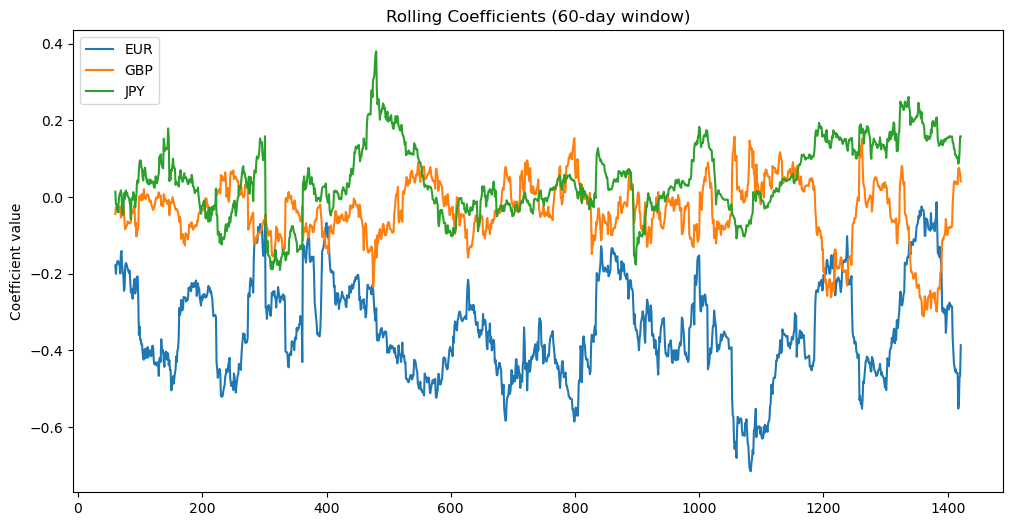

In [23]:
betas[['EUR','GBP','JPY']].plot(figsize=(12,6))
plt.title("Rolling Coefficients (60-day window)")
plt.ylabel("Coefficient value")
plt.show()

In [ ]:
#interpretation : The rolling regression results reveal substantial time variation in the estimated coefficients, indicating that the relationship between USD/TND and global FX rates is not stable. This suggests that a static OLS model may not fully capture the underlying dynamics.

In [24]:
# Approach 3 : Constrained regression
import pandas as pd
import numpy as np

y = returns['r_USD_TND']

X_cons = pd.DataFrame({
    'EUR': -returns['r_EURUSD'],
    'GBP': -returns['r_GBPUSD'],
    'JPY': returns['r_USDJPY']
})


In [25]:
from scipy.optimize import minimize

def objective(w, X, y):
    y_pred = X @ w
    return np.sum((y - y_pred) ** 2)

In [26]:
constraints = ({
    'type': 'eq',
    'fun': lambda w: np.sum(w) - 1
})

bounds = [(0, 1), (0, 1), (0, 1)]

In [27]:
w0 = np.array([1/3, 1/3, 1/3])
result = minimize(
    objective,
    w0,
    args=(X_cons.values, y.values),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)
weights = pd.Series(result.x, index=['EUR', 'GBP', 'JPY'])

print(weights)
print("Sum weights:", weights.sum())
y_pred_cons = X_cons @ weights
from sklearn.metrics import r2_score, mean_squared_error

r2_cons = r2_score(y, y_pred_cons)
rmse_cons = np.sqrt(mean_squared_error(y, y_pred_cons))

print("Constrained R2:", r2_cons)
print("Constrained RMSE:", rmse_cons)

EUR    0.671591
GBP    0.127015
JPY    0.201394
dtype: float64
Sum weights: 1.0
Constrained R2: -0.17976921048656536
Constrained RMSE: 0.003496377960173958


In [ ]:
#interpretation : the model accuracy is lower than the unconstrained OLS, which suggests that the optimal weights do not sum to 1, indicating that the fixing does not fully capture the international movements, and that other factors may be at play in determining the USD/TND exchange rate.

In [ ]:
# Apporach 4 : Ridge and lasso
